# Analisis Data Kesuburan Tanah Menggunakan K-Nearest Neighbors (KNN)

Notebook ini berisi dokumentasi analisis dataset klasifikasi kesuburan tanah menggunakan workflow KNIME, mulai dari pembacaan data, preprocessing, pembagian data, pemodelan KNN, hingga evaluasi performa model.


## 1. Deskripsi Dataset

Dataset kesuburan tanah terdiri dari **2.000 sampel** dengan **10 fitur agronomis** dan **1 kolom label**. Target klasifikasi dibagi menjadi dua kelas, yaitu **Subur** dan **Tidak Subur**. Dataset ini mengandung *missing values* sehingga perlu dilakukan preprocessing sebelum dimasukkan ke model.

### Distribusi Kelas

| Label | Jumlah Sampel | Persentase |
|---|---:|---:|
| Subur | 1.000 | 50% |
| Tidak Subur | 1.000 | 50% |
| **Total** | **2.000** | **100%** |

Dataset yang seimbang sangat membantu proses klasifikasi karena mengurangi risiko bias model terhadap salah satu kelas.


## 2. Workflow Analisis di KNIME

Analisis dilakukan menggunakan alur kerja berikut:

```text
Excel Reader → Missing Value → One to Many → Normalizer → Table Partitioner → KNN → Scorer
```

### Flowchart

```text
[Excel Reader]
      ↓
[Missing Value]
      ↓
[One to Many]
      ↓
[Normalizer]
      ↓
[Table Partitioner 80:20]
   ↙                ↘
[Training Data]   [Testing Data]
        ↘        ↙
   [K Nearest Neighbor]
            ↓
         [Scorer]
            ↓
[Accuracy, Precision, Recall, F1-Score, Confusion Matrix]
```


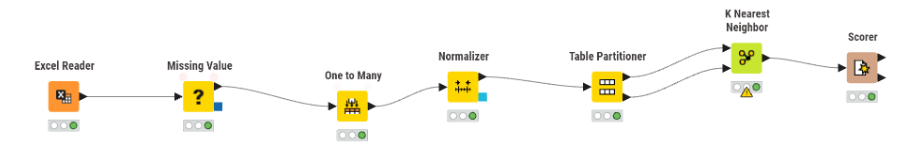


## 3. Tahapan yang Dikerjakan

### 3.1 Excel Reader
Node **Excel Reader** digunakan untuk membaca dataset dari file Excel. Pada tahap ini, seluruh fitur dan label dimasukkan ke KNIME agar dapat diproses pada tahapan berikutnya.

### 3.2 Missing Value
Node **Missing Value** digunakan untuk menangani data yang kosong. Untuk fitur numerik, nilai yang hilang diisi menggunakan rata-rata (*mean*), sedangkan untuk fitur kategorikal digunakan modus atau nilai yang paling sering muncul.

### 3.3 One to Many
Node **One to Many** digunakan untuk mengubah fitur kategorikal **Tekstur Tanah** menjadi bentuk numerik menggunakan metode **one-hot encoding**. Tahap ini penting karena algoritma KNN hanya dapat memproses data numerik.

### 3.4 Normalizer
Node **Normalizer** digunakan untuk menyamakan skala semua fitur. Karena KNN bekerja berdasarkan jarak antar data, maka fitur dengan rentang nilai besar perlu dinormalisasi agar tidak mendominasi hasil perhitungan.

### 3.5 Table Partitioner
Node **Table Partitioner** digunakan untuk membagi data menjadi dua bagian, yaitu **80% data training** dan **20% data testing**. Pembagian dilakukan dengan **stratified sampling** agar proporsi kelas tetap seimbang pada kedua bagian data.

### 3.6 K Nearest Neighbor
Node **K Nearest Neighbor** digunakan sebagai model klasifikasi. Parameter yang digunakan adalah **k = 5** dengan jarak **Euclidean**. Model menentukan kelas data uji berdasarkan mayoritas dari lima tetangga terdekat.

### 3.7 Scorer
Node **Scorer** digunakan untuk mengevaluasi performa model dengan membandingkan label asli dan hasil prediksi. Dari node ini diperoleh confusion matrix dan metrik evaluasi seperti accuracy, precision, recall, dan F1-score.


## 4. Hasil Evaluasi Model

Berdasarkan hasil pengujian pada data testing sebanyak **400 data**, model menghasilkan confusion matrix sebagai berikut.

| Actual \\ Prediksi | Tidak Subur | Subur |
|---|---:|---:|
| Tidak Subur | 202 | 0 |
| Subur | 0 | 198 |

### Identifikasi Nilai
- **TP (Subur → Subur)** = 198
- **TN (Tidak Subur → Tidak Subur)** = 202
- **FP (Tidak Subur → Subur)** = 0
- **FN (Subur → Tidak Subur)** = 0

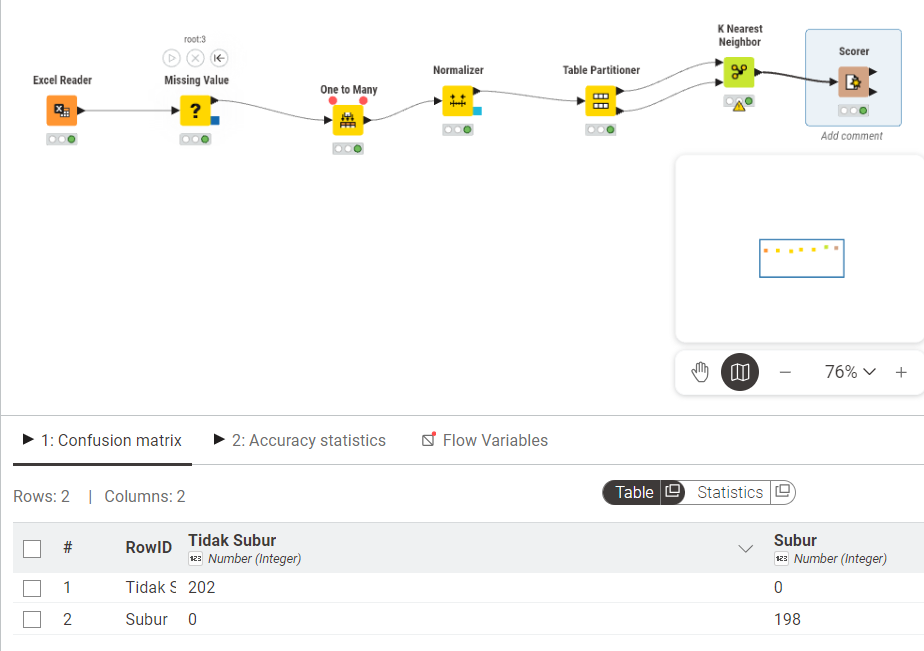

## 5. Perhitungan Metrik Evaluasi

### Accuracy
`Accuracy = (TP + TN) / (TP + TN + FP + FN)`

`= (198 + 202) / 400 = 400 / 400 = 1.0 = 100%`

### Precision
`Precision = TP / (TP + FP)`

`= 198 / (198 + 0) = 1.0 = 100%`

### Recall
`Recall = TP / (TP + FN)`

`= 198 / (198 + 0) = 1.0 = 100%`

### F1-Score
`F1-Score = 2 × (Precision × Recall) / (Precision + Recall)`

`= 2 × (1.0 × 1.0) / (1.0 + 1.0) = 1.0 = 100%`

### Ringkasan

| Metrik | Nilai |
|---|---:|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |


## 6. Interpretasi Hasil

Hasil evaluasi menunjukkan bahwa model KNN mampu mengklasifikasikan seluruh data uji dengan benar. Nilai accuracy, precision, recall, dan F1-score yang mencapai **100%** menandakan bahwa model memiliki performa yang sangat tinggi pada dataset ini.

Walaupun demikian, hasil yang sempurna tetap perlu dianalisis dengan hati-hati. Ada kemungkinan bahwa pola pada dataset sangat jelas, distribusi data terlalu ideal, atau data testing memiliki karakteristik yang sangat mirip dengan data training.

> **Catatan:** Untuk memastikan model benar-benar general dan tidak mengalami overfitting, sebaiknya dilakukan pengujian tambahan menggunakan data baru atau validasi silang.


**Accuracy Statistics**
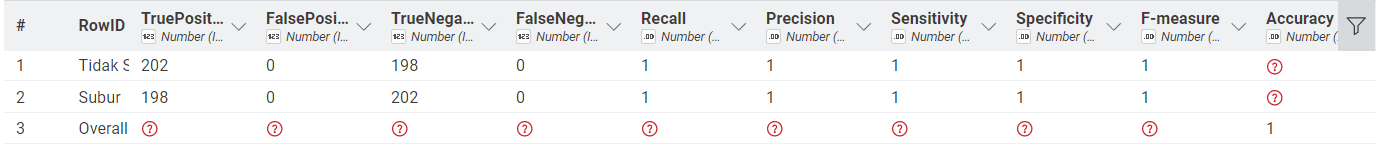
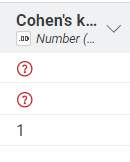

## 7. Kesimpulan

Berdasarkan workflow KNIME yang telah dibuat, analisis data kesuburan tanah menggunakan algoritma K-Nearest Neighbors (KNN) berhasil dilakukan dengan baik. Tahapan preprocessing seperti penanganan missing value, encoding, dan normalisasi terbukti penting dalam menyiapkan data agar siap digunakan oleh model.

Dengan parameter **k = 5** dan evaluasi menggunakan data testing, model menunjukkan performa sangat tinggi. Hasil ini memperlihatkan bahwa KNN dapat digunakan sebagai metode klasifikasi yang efektif untuk membedakan tanah subur dan tidak subur pada dataset yang digunakan.
